In [ ]:
!pip install -q augly
!pip install -q librosa
!pip install torchinfo

import os
from google.colab import drive
if not os.path.exists('/content/drive'):
   drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 49.7 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 170 (delta 8), reused 0 (delta 0), pack-reused 149 (from 1)
Receiving objects: 100% (170/170), 1.54 MiB | 5.13 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/Final-year-project-2026


In [ ]:
import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image

import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image

class DroneFusionDatasetH5(Dataset):
    def __init__(
        self,
        h5_path,
        transform=None,  # Dict containing your get_audio_transform, get_img_transform, etc.
        audio_feature_type='logmel',
        modalities=['audio', 'video', 'rf'],
        is_training=True,
        n_mfcc=40,
        n_fft=2048,
        hop_length=512,
        n_mels=64,
        segment_length=0.25
    ):
        self.h5_path = h5_path
        self.audio_feature_type = audio_feature_type.lower()
        self.modalities = [m.lower() for m in modalities]
        self.is_training = is_training

        self.transform = transform or {}
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.segment_length = segment_length

        if not os.path.exists(self.h5_path):
            raise FileNotFoundError(f"HDF5 file not found at: {self.h5_path}")

        # Extract metadata
        with h5py.File(self.h5_path, 'r') as f:
            self.length = len(f['labels'])
            # Native SR from the H5 attributes (set during packing)
            self.native_sr = int(f.attrs.get('sr', 44100))

    def _extract_logmel(self, y, sr):
        # Exact logic from your original loader
        target_frames = int(np.ceil(self.segment_length / (138 / sr)))

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=138,
            n_mels=self.n_mels, power=2.0
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Z-score normalization
        log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

        if log_mel.shape[1] < target_frames:
            pad_width = target_frames - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
        else:
            log_mel = log_mel[:, :target_frames]

        return torch.from_numpy(log_mel).unsqueeze(0).float()

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open inside getitem for DataLoader worker safety
        with h5py.File(self.h5_path, 'r') as f:
            # 1. Label
            label = torch.tensor(f['labels'][idx], dtype=torch.long)

            # 2. Audio Processing
            audio_tensor = torch.empty(0)
            if 'audio' in self.modalities:
                waveform = f['audio'][idx].astype(np.float32)
                sr = self.native_sr

                # Apply your custom get_audio_transform (augly/logmel_augment)
                if 'audio' in self.transform:
                    waveform, sr = self.transform['audio'](waveform, sr)

                if self.audio_feature_type == 'logmel':
                  # Resample only for Log-Mel
                  waveform = librosa.resample(waveform, orig_sr=self.native_sr, target_sr=22050)
                  sr = 22050

                  max_val = np.max(np.abs(waveform))
                  if max_val > 0: waveform /= max_val
                  audio_tensor = self._extract_logmel(waveform, sr)
                else:
                    # MFCC "Diff Sampling" [::3]
                    waveform_sub = np.asfortranarray(waveform[::3])
                    mfcc = librosa.feature.mfcc(
                        y=waveform_sub, sr=sr, n_mfcc=self.n_mfcc,
                        n_fft=self.n_fft, hop_length=self.hop_length
                    )
                    pad_width = max(0, self.n_mfcc - mfcc.shape[1])
                    if pad_width > 0:
                        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
                    audio_tensor = torch.from_numpy(mfcc).float().unsqueeze(0)

            # 3. Video Processing (Using your get_img_transform)
            video_tensor = torch.empty(0)
            if 'video' in self.modalities:
                video_data = f['video'][idx]
                v_trans = self.transform.get('video')
                if v_trans:
                    # Logic: uint8 -> PIL -> your Compose (ToTensor + Augments + Normalize)
                    v_frames = [v_trans(Image.fromarray(video_data[i])) for i in range(len(video_data))]
                    video_tensor = torch.stack(v_frames)

            # 4. RF Processing (Using your get_rf_transform)
            rf_tensor = torch.empty(0)
            if 'rf' in self.modalities:
                rf_data = f['rf'][idx]
                rf_trans = self.transform.get('rf')
                if rf_trans:
                    # Logic: uint8 -> PIL -> your Compose (Resize + ToTensor + rf_aug + Normalize)
                    rf_frames = [rf_trans(Image.fromarray(rf_data[i])) for i in range(len(rf_data))]
                    rf_tensor = torch.stack(rf_frames)

        return audio_tensor, video_tensor, rf_tensor, label

In [ ]:
from torch.utils.data import DataLoader
class Args:
    dataset_dir = '/content/drive/MyDrive/data'
    batch_size = 32
    feature_type = 'logmel'  # Changed to 'logmel' to match model's expected input

    # Dynamic parameter selection based on original loader requirements
    n_mfcc = 40
    n_mels = 64 if feature_type == 'logmel' else 40
    num_workers = min(8, os.cpu_count())
    pin_memory = True
    modalities = ['audio']
    crop_size = 112

args = Args()

# --- 3. Setup Transforms ---
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

train_transform = {
    'audio': get_audio_transform(args, is_training=True, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=True, augment=True),
    'rf': get_rf_transform(args, is_training=True, augment=True)
}

val_transform = {
    'audio': get_audio_transform(args, is_training=False, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=False, augment=False),
    'rf': get_rf_transform(args, is_training=False, augment=False)
}

# --- 4. Initialize Datasets & Loaders ---

train_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Train.h5'),
    transform=train_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=True
)

val_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Validation.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


test_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Test.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


loaders = {
    'train': DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'val': DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory),
    'test': DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory)
}

# --- 5. Final Printing and Verification ---
print(f"--- Dataset Summary ---")
print(f"Train Samples: {len(train_dataset)} | Batches: {len(loaders['train'])}")
print(f"Val Samples:   {len(val_dataset)} | Batches: {len(loaders['val'])}")
print(f"Val Samples:   {len(test_dataset)} | Batches: {len(loaders['test'])}\n")
print(f"--- Input Shape Verification ---")

audio_b, video_b, rf_b, label_b = next(iter(loaders['train']))
print(f"Audio Shape: {audio_b.shape}")
print(f"Video Shape: {video_b.shape}")
print(f"RF Shape:    {rf_b.shape}")
print(f"Label Shape: {label_b.shape}")

--- Dataset Summary ---
Train Samples: 8480 | Batches: 265
Val Samples:   1280 | Batches: 40
Val Samples:   1320 | Batches: 42

--- Input Shape Verification ---
Audio Shape: torch.Size([32, 1, 64, 40])
Video Shape: torch.Size([32, 0])
RF Shape:    torch.Size([32, 0])
Label Shape: torch.Size([32])


In [ ]:
# ==========================================
# MODULAR TRAINING & EVALUATION (STATIC LABELS + LATENCY)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import copy
import time

# --------------------------
# 1️⃣ Training Function
# --------------------------
import torch
import torch.nn as nn
import copy
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def train_unimodal(model, dataloaders, device, optimizer, criterion, num_epochs=10, modal_num=0):
    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # تحديد نوع الـ Loss تلقائياً بناءً على مخرجات الموديل
    # إذا كان الموديل ينتهي بـ Sigmoid نستخدم BCELoss، إذا كان Logits نستخدم BCEWithLogitsLoss
    # لكن الأفضل توحيد الـ Criterion من الخارج وتجهيز البيانات هنا

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for batch in tqdm(dataloaders[phase], desc=f"{phase.upper()}", leave=False):
                # 1. تجهيز المدخلات (تلقائياً حسب الـ Modal المطلوبة)
                inputs = batch[modal_num].to(device).float()

                # 2. تجهيز الـ Labels وضمان أنها float وبأبعاد 1D لتجنب الـ Broadcasting Error
                labels = batch[-1].to(device).float().view(-1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # 3. تمرير البيانات (Forward Pass) مع ضمان توحيد الأبعاد للمخرج
                    outputs = model(inputs).view(-1)

                    # 4. حساب الخسارة
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 5. حساب الإحصائيات
                running_loss += loss.item() * inputs.size(0)

                # تحويل المخرجات إلى توقعات (0 أو 1)
                # ملاحظة: إذا كان الموديل لا يحتوي Sigmoid (مثل AudioVGG19)، نطبقها هنا يدوياً للمقاييس فقط
                preds_probs = torch.sigmoid(outputs) if not any(isinstance(m, nn.Sigmoid) for m in model.modules()) else outputs
                preds = (preds_probs > 0.5).long()

                all_preds.append(preds.detach().cpu())
                all_labels.append(labels.detach().cpu().long())

            # حساب النتائج النهائية للـ Epoch
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            y_true = torch.cat(all_labels).numpy()
            y_pred = torch.cat(all_preds).numpy()
            epoch_acc = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # حفظ أفضل نسخة من الموديل بناءً على دقة التحقق (Validation Accuracy)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f" New Best Model! Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

# --------------------------
# 2️⃣ Testing Function (with latency)
# --------------------------
def test_unimodal(model, dataloader, device, modal_num=0, dataset_name="Dataset"):
    model.eval()
    all_preds, all_labels = [], []
    total_time, total_samples = 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Testing {dataset_name}"):
            inputs = batch[modal_num].to(device).float()
            # تعديل 1: ضمان أن الـ labels بتنسيق 1D وموحد
            labels = batch[-1].to(device).long().view(-1)

            # التوقيت (Inference Latency)
            if device.type == 'cuda': torch.cuda.synchronize()
            start = time.time()

            # تعديل 2: ضمان أن المخرج 1D ليتوافق مع الـ labels
            outputs = model(inputs).view(-1)

            if device.type == 'cuda': torch.cuda.synchronize()
            total_time += (time.time() - start)

            # تعديل 3: التعامل مع الـ Sigmoid إذا لم تكن موجودة في الموديل
            # بعض موديلاتك (AudioVGG19) لا تملك Sigmoid داخلها
            if not any(isinstance(m, nn.Sigmoid) for m in model.modules()):
                preds_probs = torch.sigmoid(outputs)
            else:
                preds_probs = outputs

            preds = (preds_probs > 0.5).long()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            total_samples += inputs.size(0)

    # حساب المقاييس النهائية
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    avg_ms = (total_time / total_samples) * 1000
    fps = 1000 / avg_ms

    print(f"\n===== {dataset_name} Results =====")
    print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")
    print(f"Latency: {avg_ms:.2f} ms/sample | FPS: {fps:.2f}")
    print("===============================\n")

    return {
        'y_true': y_true, 'y_pred': y_pred,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1,
        'avg_ms': avg_ms, 'fps': fps
    }

# --------------------------
# 3️⃣ Plot Training History
# --------------------------
def plot_training_history(history):
    epochs = range(1,len(history['train_loss'])+1)
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'],  label='Val Loss')
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# --------------------------
# 4️⃣ Confusion Matrix
# --------------------------
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    class_names = ["No-Drone","Drone"]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --------------------------
# 5️⃣ Per-Class Metrics Bar Plot
# --------------------------
def plot_per_class_metrics_group(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    accuracy = [accuracy_score(y_true, y_pred)]*len(class_names)

    paired_colors = ['#1f78b4','#a6cee3','#b2df8a','#33a02c']
    x = np.arange(len(class_names))
    width = 0.2

    plt.figure(figsize=(8,5))
    plt.bar(x-1.5*width, precision, width, label="Precision", color=paired_colors[0])
    plt.bar(x-0.5*width, recall, width, label="Recall", color=paired_colors[1])
    plt.bar(x+0.5*width, f1, width, label="F1-score", color=paired_colors[2])
    plt.bar(x+1.5*width, accuracy, width, label="Accuracy", color=paired_colors[3])
    plt.xticks(x,class_names)
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.title(f"Per-Class Metrics ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------
# 6️⃣ Classification Report
# --------------------------
def print_classification_report(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    print(f"\n===== {dataset_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class LogMelCNN_64(nn.Module):
    def __init__(self):
        super(LogMelCNN_64, self).__init__()

        # Conv Block 1: 64x40 -> 32x20 (after pool)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Block 2: 32x20 -> 16x10 (after pool)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv Block 3: 16x10 -> 8x5 (after pool)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)

        # Flattened size: 128 channels * 8 height * 5 width = 5120
        self.fc1 = nn.Linear(128 * 8 * 5, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, 1, 64, 40]
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.classifier(x)
        return out.squeeze()



Epoch 1/10


TRAIN -> Loss: 0.4298 | Acc: 0.7985


VAL -> Loss: 0.2410 | Acc: 0.9047
 New Best Model! Acc: 0.9047

Epoch 2/10


TRAIN -> Loss: 0.3504 | Acc: 0.8436


VAL -> Loss: 0.2362 | Acc: 0.9039

Epoch 3/10


...

VAL -> Loss: 0.1525 | Acc: 0.9430

Epoch 9/10


TRAIN -> Loss: 0.2446 | Acc: 0.8895


VAL -> Loss: 0.1443 | Acc: 0.9437

Epoch 10/10


TRAIN -> Loss: 0.2335 | Acc: 0.8969


VAL -> Loss: 0.1283 | Acc: 0.9523
 New Best Model! Acc: 0.9523


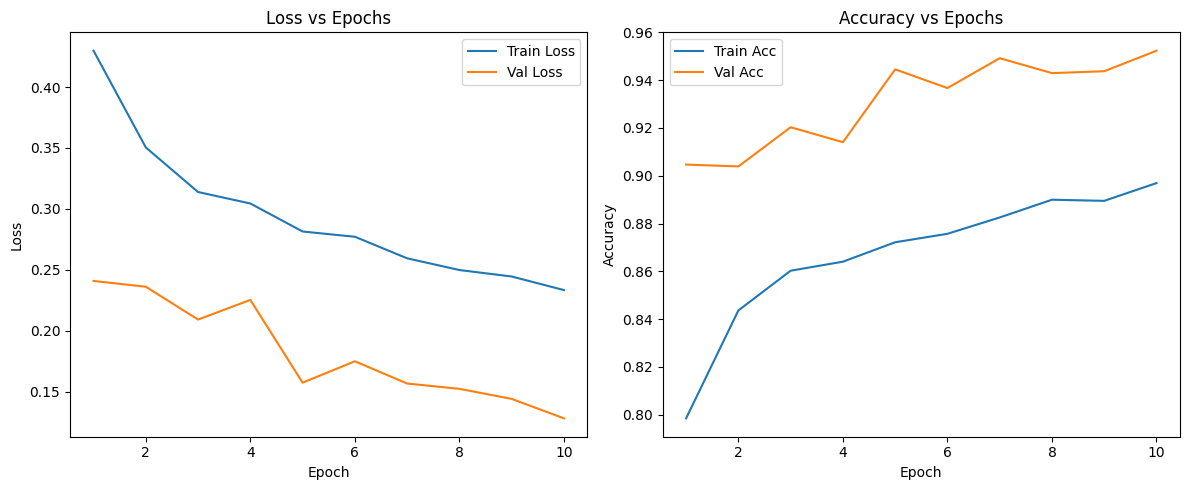

Testing Train: 100%|██████████| 265/265 [02:08<00:00,  2.06it/s]



===== Train Results =====
Accuracy: 0.9047 | F1: 0.9129
Precision: 0.9293 | Recall: 0.8970
Latency: 0.14 ms/sample | FPS: 7009.04


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8761    0.9144    0.8948      3760
       Drone     0.9293    0.8970    0.9129      4720

    accuracy                         0.9047      8480
   macro avg     0.9027    0.9057    0.9039      8480
weighted avg     0.9057    0.9047    0.9049      8480



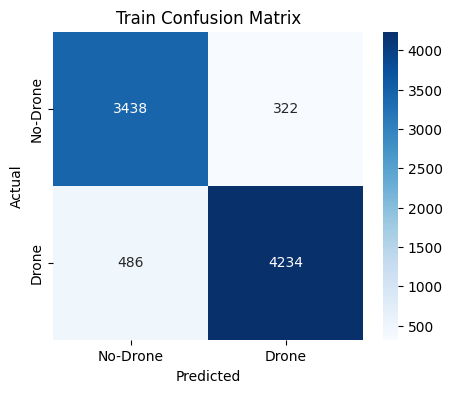

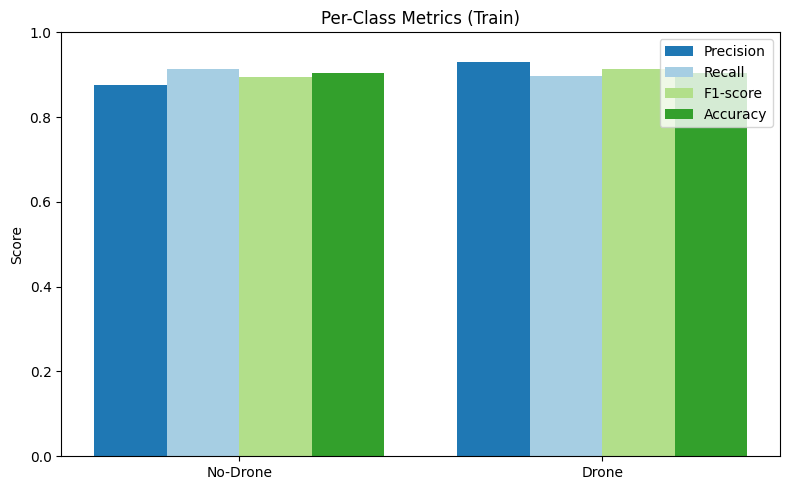

In [ ]:
model = LogMelCNN_64().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# الترتيب الصحيح حسب تعريف الدالة العالمية:
model, history = train_unimodal(
    model,
    loaders,
    device,
    optimizer,   # الـ Adam (المحسن) في الخانة الرابعة
    criterion,   # الـ BCELoss (دالة الخسارة) في الخانة الخامسة
    num_epochs=10,
    modal_num=0
)
#  loss VS accuracy
plot_training_history(history)

train_metrics = test_unimodal(model, loaders['train'], device, dataset_name="Train", modal_num=0)
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")


Testing Validation: 100%|██████████| 40/40 [00:18<00:00,  2.15it/s]



===== Validation Results =====
Accuracy: 0.9523 | F1: 0.9617
Precision: 0.9660 | Recall: 0.9575
Latency: 0.14 ms/sample | FPS: 7253.14


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9302    0.9437    0.9369       480
       Drone     0.9660    0.9575    0.9617       800

    accuracy                         0.9523      1280
   macro avg     0.9481    0.9506    0.9493      1280
weighted avg     0.9525    0.9523    0.9524      1280



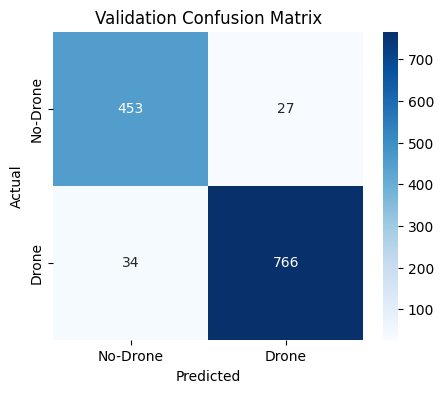

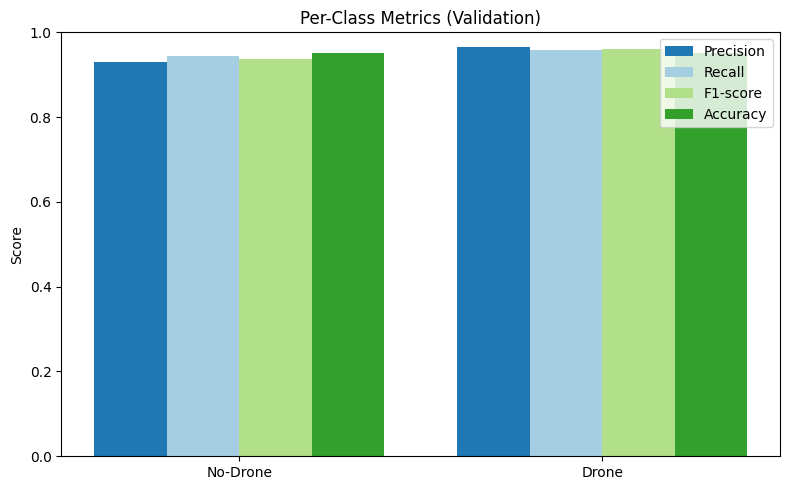

In [ ]:
val_metrics   = test_unimodal(model, loaders['val'], device, dataset_name="Validation", modal_num=0)
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")

Testing Test: 100%|██████████| 42/42 [00:22<00:00,  1.86it/s]



===== Test Results =====
Accuracy: 0.9394 | F1: 0.9509
Precision: 0.9810 | Recall: 0.9226
Latency: 0.13 ms/sample | FPS: 7726.25


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8774    0.9688    0.9208       480
       Drone     0.9810    0.9226    0.9509       840

    accuracy                         0.9394      1320
   macro avg     0.9292    0.9457    0.9359      1320
weighted avg     0.9433    0.9394    0.9400      1320



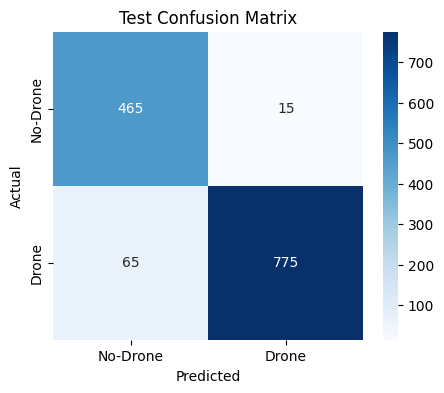

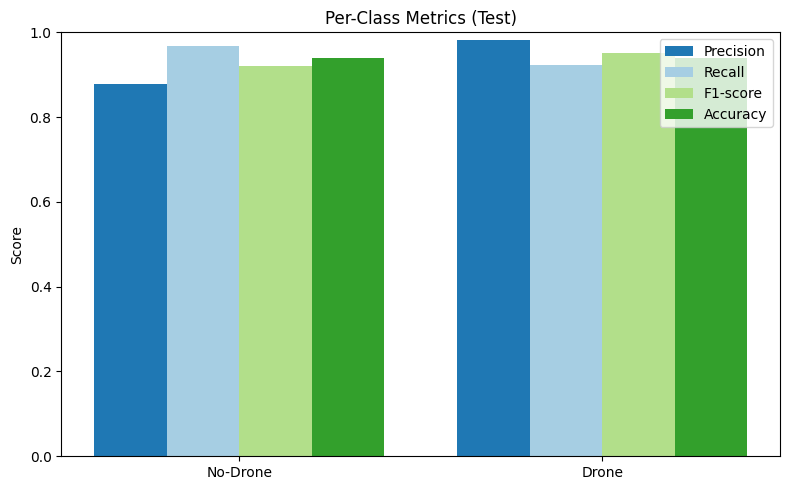

In [ ]:
test_metrics  = test_unimodal(model, loaders['test'], device, dataset_name="Test", modal_num=0)
print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")
plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")

In [ ]:
import os
import pickle
import torch
save_dir = "/content/drive/MyDrive/UniModel result"
os.makedirs(save_dir, exist_ok=True)
model_name = "Audio_LogMelCNN_64"

#Save model weights
weights_path = os.path.join(save_dir, f"{model_name}_weights.pth")
torch.save(model.state_dict(), weights_path)
print(f"Saved model weights -> {weights_path}")

#Save all results including detection time
results = {
    'history': history,
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'detection_time': {
        'avg_time_per_sample': test_metrics['avg_ms'],  # in milliseconds
        'fps': test_metrics['fps']
    }
}

results_path = os.path.join(save_dir, f"{model_name}_results.pkl")
with open(results_path, 'wb') as f:
    pickle.dump(results, f)
print(f"Saved all results -> {results_path}")

Saved model weights -> /content/drive/MyDrive/UniModel result/Audio_LogMelCNN_64_weights.pth
Saved all results -> /content/drive/MyDrive/UniModel result/Audio_LogMelCNN_64_results.pkl


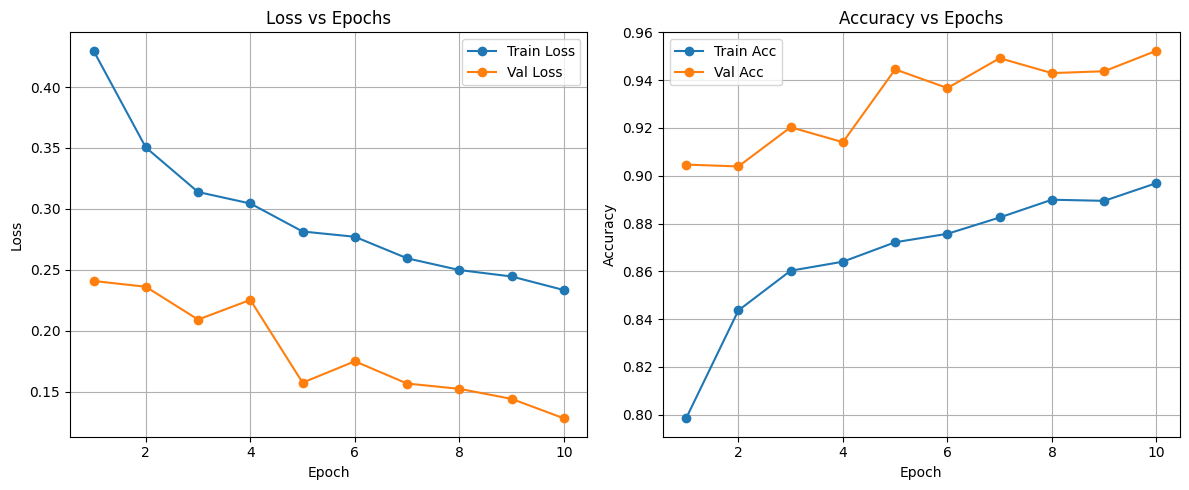

In [ ]:
import pickle
import matplotlib.pyplot as plt

# Path to your saved results
results_path = "/content/drive/MyDrive/UniModel result/Audio_LogMelCNN_64_results.pkl"

# Load results
with open(results_path, 'rb') as f:
    results = pickle.load(f)

history = results['history']

# Plot Loss and Accuracy
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
plt.plot(epochs, history['val_loss'], 'o-',  label='Val Loss' )
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
plt.plot(epochs, history['val_acc'], 'o-', label='Val Acc')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()